## D2C Customer Churn Capstone — Part 2: RFM Customer Segmentation

### Notebook Objectives:
1. **Build RFM Features:** Calculate Recency, Frequency, and Monetary metrics for our customer cohort over a 180-day pre-snapshot order window.
2. **Define and Justify 5 Customer Segments:** Formulate logical criteria to slice our customer database into *Champions*, *Loyal Customers*, *At-Risk Customers*, *Discount-Sensitive Customers*, and *Dormant Customers*.
3. **Incorporate Non-RFM Signals:** Enhance our RFM segments by integrating customer service complaints and order return histories.
4. **Visualize Segment Profiles:** Profile segments through statistical checks and visual charts.
5. **Export Segment Datasets:** Save results as `segments.csv` for strategic campaigns.

In [15]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

## 1. Load Datasets & Self-Healing Pipeline

To guarantee standalone notebook execution, we load our raw datasets and execute our deduplication and demographical imputation pipelines inline in memory.

In [ ]:
# Define raw data paths
raw_dir = "../data"

customers = pd.read_csv(os.path.join(raw_dir, "customers.csv"))
orders = pd.read_csv(os.path.join(raw_dir, "orders.csv"))
support_tickets = pd.read_csv(os.path.join(raw_dir, "support_tickets.csv"))
web_events = pd.read_csv(os.path.join(raw_dir, "web_events_snapshot.csv"))
churn_labels = pd.read_csv(os.path.join(raw_dir, "churn_labels.csv"))
intervention = pd.read_csv(os.path.join(raw_dir, "intervention_history.csv"))

# 1. Strip orders duplicates ending in _DUP
orders = orders[~orders['order_id'].str.contains('_DUP', na=False)].copy()

# 2. Demographics Imputations
customers['loyalty_tier'] = customers['loyalty_tier'].fillna('None')
customers['skin_type'] = customers['skin_type'].fillna('Unknown').replace('NA', 'Unknown')

# 3. Spend outliers treatment (Clip gross amount to 99th percentile)
spend_99th = orders['gross_amount'].quantile(0.99)
orders['gross_amount'] = orders['gross_amount'].clip(upper=spend_99th)

# 4. Prevent Leakage: partition order logs to pre-snapshot
orders['order_date'] = pd.to_datetime(orders['order_date'])
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
snapshot_date = pd.to_datetime("2025-09-30")
orders_pre = orders[orders['order_date'] <= snapshot_date].copy()

print("Datasets loaded and inline audit pipeline applied successfully.")

Raw data folder: c:\Users\agraw\OneDrive\Desktop\masai_capstone\part-2\data
Datasets loaded and inline audit pipeline applied successfully.


--- 
## 2. RFM & Behavioral Signals Calculation

We calculate Recency, Frequency, and Monetary metrics on our pre-snapshot order history. 
- **Recency:** Days since last pre-snapshot transaction.
- **Frequency (180d):** Count of orders in the 180-day window (`2025-04-03` to `2025-09-30` inclusive).
- **Monetary (180d):** Sum of gross spends in the 180-day window.

To enhance our segmentation, we also compute:
- **Avg Discount Percentage:** Mean discount fraction applied across orders.
- **Return Rate:** Proportion of orders returned in the 180-day window.
- **Ticket Count (90d):** Complaints raised in the 90 days before snapshot (`2025-07-02` to `2025-09-30` inclusive).

In [17]:
# A. Calculate Recency (using entire pre-snapshot order history)
latest_order = orders_pre.groupby('customer_id')['order_date'].max().reset_index()
latest_order['recency_days'] = (snapshot_date - latest_order['order_date']).dt.days

# B. Define 180-day and 90-day start dates
start_180d = snapshot_date - pd.Timedelta(days=180)
start_90d = snapshot_date - pd.Timedelta(days=90)

# C. Filter orders and tickets to their respective windows
orders_180d = orders_pre[orders_pre['order_date'] >= start_180d].copy()
tickets_90d = support_tickets[pd.to_datetime(support_tickets['ticket_date']) >= start_90d].copy()

# D. Aggregate order metrics
rfm_180d = orders_180d.groupby('customer_id').agg(
    frequency_180d=('order_id', 'count'),
    monetary_180d=('gross_amount', 'sum'),
    return_rate_180d=('returned', 'mean'),
    avg_discount_pct_180d=('discount_pct', 'mean')
).reset_index()

# E. Aggregate support complaints
support_90d = tickets_90d.groupby('customer_id')['ticket_id'].count().reset_index().rename(columns={'ticket_id': 'ticket_count_90d'})

# F. Calculate days_since_signup
customers['days_since_signup'] = (snapshot_date - customers['signup_date']).dt.days

# G. Combine features
features_df = pd.merge(customers[['customer_id', 'days_since_signup']], latest_order[['customer_id', 'recency_days']], on='customer_id', how='left')
features_df = pd.merge(features_df, rfm_180d, on='customer_id', how='left')
features_df = pd.merge(features_df, support_90d, on='customer_id', how='left')

# Apply logical baseline fills for non-active/complaint-free customers
features_df['recency_days'] = features_df['recency_days'].fillna(features_df['days_since_signup']) # if never ordered, recency = days_since_signup
features_df['frequency_180d'] = features_df['frequency_180d'].fillna(0).astype(int)
features_df['monetary_180d'] = features_df['monetary_180d'].fillna(0.0)
features_df['return_rate_180d'] = features_df['return_rate_180d'].fillna(0.0)
features_df['avg_discount_pct_180d'] = features_df['avg_discount_pct_180d'].fillna(0.0)
features_df['ticket_count_90d'] = features_df['ticket_count_90d'].fillna(0).astype(int)

display(features_df.head(10))

,customer_id,days_since_signup,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,ticket_count_90d
0,CUST00001,524,107,1,362.73,0.00,0.230000,0
1,CUST00002,121,40,1,581.00,0.00,0.230000,1
2,CUST00003,206,171,1,649.98,0.00,0.470000,0
3,CUST00004,168,131,1,1604.04,0.00,0.160000,0
4,CUST00005,405,38,3,1781.90,0.00,0.480000,0
5,CUST00006,365,51,4,2989.58,0.25,0.380000,2
6,CUST00007,68,3,1,719.33,0.00,0.180000,0
7,CUST00008,316,47,3,2449.11,0.00,0.216667,0
8,CUST00009,41,31,1,376.85,0.00,0.490000,0
9,CUST00010,28,9,1,636.80,0.00,0.450000,0


--- 
## 3. Justified 5-Segment Logic

We assign our customers into **exactly 5 categories** based on RFM quantiles and behavioral signals:

1. **Champions:** High frequency, recent orders, and substantial gross spend. Highly active brand advocates.
2. **Loyal Customers:** Frequent buyers with steady recencies. Steady, high-frequency base.
3. **At-Risk Customers:** Past high-value, frequent buyers who have not ordered in a long time (recency exceeds 90 days).
4. **Discount-Sensitive Customers:** Frequent buyers whose average transaction discount exceeds 35%. They actively seek sales.
5. **Dormant Customers:** Customers who haven't ordered in over 150 days and had low transaction volumes to begin with.

In [18]:
def segment_customer(row):
    rec = row['recency_days']
    freq = row['frequency_180d']
    mon = row['monetary_180d']
    disc = row['avg_discount_pct_180d']
    tkt = row['ticket_count_90d']
    
    # 1. Dormant
    if rec > 150 and freq <= 1:
        return 'Dormant Customers'
    
    # 2. At-Risk
    elif rec > 90 and freq >= 2:
        return 'At-Risk Customers'
    
    # 3. Discount-Sensitive
    elif disc >= 0.35 and freq >= 1:
        return 'Discount-Sensitive Customers'
    
    # 4. Champions
    elif rec <= 45 and freq >= 3 and mon >= 1500:
        return 'Champions'
    
    # 5. Loyal Customers (steady active base)
    else:
        return 'Loyal Customers'

# Apply deterministic segmentation logic
features_df['segment_name'] = features_df.apply(segment_customer, axis=1)

print("Customer counts across segments:")
print(features_df['segment_name'].value_counts())
display(features_df.head(10))

Customer counts across segments:
segment_name
Loyal Customers                 1100
Discount-Sensitive Customers     483
Dormant Customers                431
At-Risk Customers                195
Champions                        191
Name: count, dtype: int64


,customer_id,days_since_signup,recency_days,frequency_180d,monetary_180d,return_rate_180d,avg_discount_pct_180d,ticket_count_90d,segment_name
0,CUST00001,524,107,1,362.73,0.00,0.230000,0,Loyal Customers
1,CUST00002,121,40,1,581.00,0.00,0.230000,1,Loyal Customers
2,CUST00003,206,171,1,649.98,0.00,0.470000,0,Dormant Customers
3,CUST00004,168,131,1,1604.04,0.00,0.160000,0,Loyal Customers
4,CUST00005,405,38,3,1781.90,0.00,0.480000,0,Discount-Sensitive Customers
5,CUST00006,365,51,4,2989.58,0.25,0.380000,2,Discount-Sensitive Customers
6,CUST00007,68,3,1,719.33,0.00,0.180000,0,Loyal Customers
7,CUST00008,316,47,3,2449.11,0.00,0.216667,0,Loyal Customers
8,CUST00009,41,31,1,376.85,0.00,0.490000,0,Discount-Sensitive Customers
9,CUST00010,28,9,1,636.80,0.00,0.450000,0,Discount-Sensitive Customers


--- 
## 4. Visualizing Customer Segments

Let's plot segment counts and distributions to visualize their behaviors.

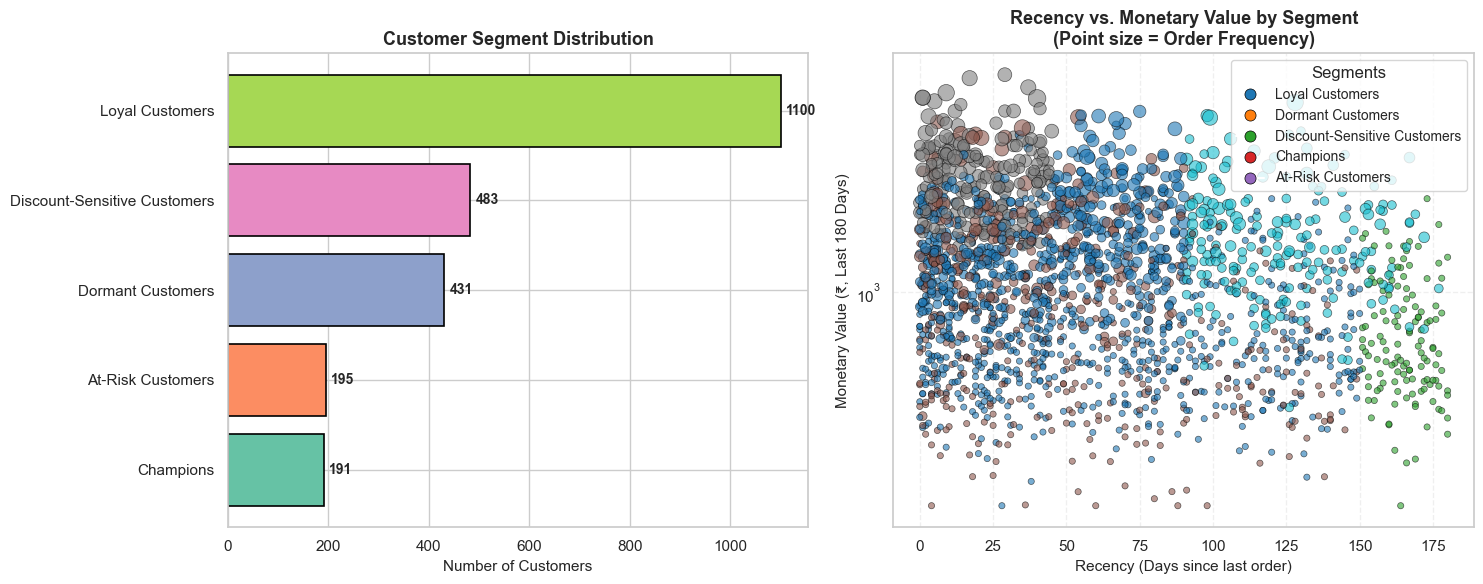


Segment Profile Summary:
Total customers analyzed: 2,400
Customers with monetary activity: 2,098 (87.4%)


In [19]:
# Plot 1: Segment size counts
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Left: Segment counts with value labels
segment_counts = features_df['segment_name'].value_counts().sort_values(ascending=True)
colors_seg = sns.color_palette('Set2', len(segment_counts))
bars = ax1.barh(segment_counts.index, segment_counts.values, color=colors_seg, edgecolor='black', linewidth=1.2)
ax1.set_title('Customer Segment Distribution', fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of Customers', fontsize=11)

# Add count labels on bars
for i, (bar, count) in enumerate(zip(bars, segment_counts.values)):
    ax1.text(count + 10, bar.get_y() + bar.get_height()/2, f'{count}', 
             va='center', fontsize=10, fontweight='bold')

# Right: Recency vs. Monetary with enhanced visuals
plot_data = features_df[features_df['monetary_180d'] > 0].copy()

# Create scatter with size encoding (frequency) and hue (segment)
scatter = ax2.scatter(plot_data['recency_days'], plot_data['monetary_180d'], 
                      s=plot_data['frequency_180d']*20,  # Size represents frequency
                      c=pd.factorize(plot_data['segment_name'])[0],  # Color by segment
                      cmap='tab10', alpha=0.6, edgecolors='black', linewidth=0.5)

ax2.set_xlabel('Recency (Days since last order)', fontsize=11)
ax2.set_ylabel('Monetary Value (₹, Last 180 Days)', fontsize=11)
ax2.set_title('Recency vs. Monetary Value by Segment\n(Point size = Order Frequency)', fontsize=13, fontweight='bold')
ax2.set_yscale('log')
ax2.grid(True, alpha=0.3, linestyle='--')

# Add custom legend for segments
segment_colors = {seg: colors for seg, colors in zip(features_df['segment_name'].unique(), 
                                                       sns.color_palette('tab10', len(features_df['segment_name'].unique())))}
handles = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=segment_colors[seg], 
                       markersize=8, label=seg, markeredgecolor='black', markeredgewidth=0.5)
           for seg in features_df['segment_name'].unique()]
ax2.legend(handles=handles, title='Segments', loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

# Summary stats
print("\nSegment Profile Summary:")
print(f"Total customers analyzed: {len(features_df):,}")
print(f"Customers with monetary activity: {len(plot_data):,} ({len(plot_data)/len(features_df)*100:.1f}%)")


--- 
## 5. Segment Churn Risk Characterization

We join segment profiles with true churn labels to verify how well our segment definitions align with true customer churn.

In [20]:
validation_df = pd.merge(features_df, churn_labels[['customer_id', 'churn_next_60d']], on='customer_id', how='left')

print("Average Churn Rate across our designed RFM segments:")
segment_summary = validation_df.groupby('segment_name').agg(
    customer_count=('customer_id', 'count'),
    average_recency=('recency_days', 'mean'),
    average_frequency=('frequency_180d', 'mean'),
    average_monetary=('monetary_180d', 'mean'),
    average_tickets=('ticket_count_90d', 'mean'),
    average_discount=('avg_discount_pct_180d', 'mean'),
    true_churn_rate=('churn_next_60d', 'mean')
).reset_index()

display(segment_summary.sort_values(by='true_churn_rate', ascending=False))

Average Churn Rate across our designed RFM segments:


,segment_name,customer_count,average_recency,average_frequency,average_monetary,average_tickets,average_discount,true_churn_rate
3,Dormant Customers,431,224.006961,0.299304,222.572878,0.000000,0.082622,0.914153
0,At-Risk Customers,195,122.087179,2.374359,1748.757553,0.035897,0.278664,0.682051
2,Discount-Sensitive Customers,483,50.677019,1.683230,1057.281887,0.320911,0.418935,0.395445
4,Loyal Customers,1100,55.417273,1.541818,1183.109871,0.257273,0.225594,0.359091
1,Champions,191,20.481675,3.801047,2990.160702,0.549738,0.250102,0.073298


--- 
## 6. Export Segment Catalog

We save the customer list and segment assignments to `segments.csv` inside our local folder.

In [21]:
export_cols = [
    'customer_id', 'recency_days', 'frequency_180d', 'monetary_180d',
    'return_rate_180d', 'avg_discount_pct_180d', 'ticket_count_90d', 'segment_name'
]

# Export to part-2 folder
features_df[export_cols].to_csv("segments.csv", index=False)
print("Segments database exported successfully to segments.csv")

Segments database exported successfully to segments.csv
